In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [16]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Digits
data = load_digits()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME-NDT
explainer = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (31, 1, 1)
self.L: 31 self.C: 1
mean_leaf_values shape after squeeze: (31, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Explication locale (feature, poids):
[('pixel_19', 0.3008225826282025), ('pixel_20', 0.18827463188321458), ('pixel_10', -0.12835587708701474), ('pixel_46', 0.12191860465116282), ('pixel_58', -0.10711100339137958), ('pixel_4', -0.06779158040027604), ('pixel_27', 0.05260145487497409), ('pixel_12', 0.050086887661649065), ('pixel_0', 0.049773504273504264), ('pixel_42', -0.04690692705431692), ('pixel_26', 0.031547619047619054), ('pixel_51', 0.031000000000000014), ('pixel_50', -0.0188739309471017), ('pixel_38', -0.01460911405187676), ('pixel_33', 0.010281954887218087), ('pixel_62', 0.009619281658028046), ('pixel_44', 0.0077983267927917085), ('pixel_34', 0.007169565909452662), ('pixel_52', 0.0), ('pixel_61', 0.0), ('pixel_2', 0.0), ('pixel_5', 0.0), ('pixel_59', 0.0), ('pixel_36', 0.0), ('pixel_55', 0.0), ('pixel_9', 0.0), ('pixel_30', 0.0), ('pixel_21', 0.0), ('pixel_41', 0

In [17]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=[f'pixel_{i}' for i in range(X.shape[1])],
    class_names=[str(i) for i in range(10)],
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=64
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('pixel_10', -0.011921813212120644), ('pixel_19', 0.010222437856225364), ('pixel_20', 0.00807070074941334), ('pixel_27', 0.00742835792603167), ('pixel_42', -0.006731469644916682), ('pixel_58', -0.005917330283729862), ('pixel_38', -0.005825946742184159), ('pixel_44', 0.005810740941587958), ('pixel_52', 0.005217645071867372), ('pixel_46', -0.005017429559770859), ('pixel_12', 0.004413298357099756), ('pixel_62', 0.004241048438967366), ('pixel_43', 0.003761173493093026), ('pixel_61', 0.003739450408670075), ('pixel_36', 0.003726425140843432), ('pixel_30', -0.0037005025506448123), ('pixel_50', -0.0032251299451585224), ('pixel_28', 0.0029991530525521146), ('pixel_59', -0.0028901477124122716), ('pixel_34', 0.0026303182073433274), ('pixel_33', 0.002471667608169713), ('pixel_2', -0.002403278709619946), ('pixel_21', -0.002325464591563363), ('pixel_9', -0.00222489224215745), ('pixel_60', 0.0021082340531214045), ('pixel_26', 0.0020088

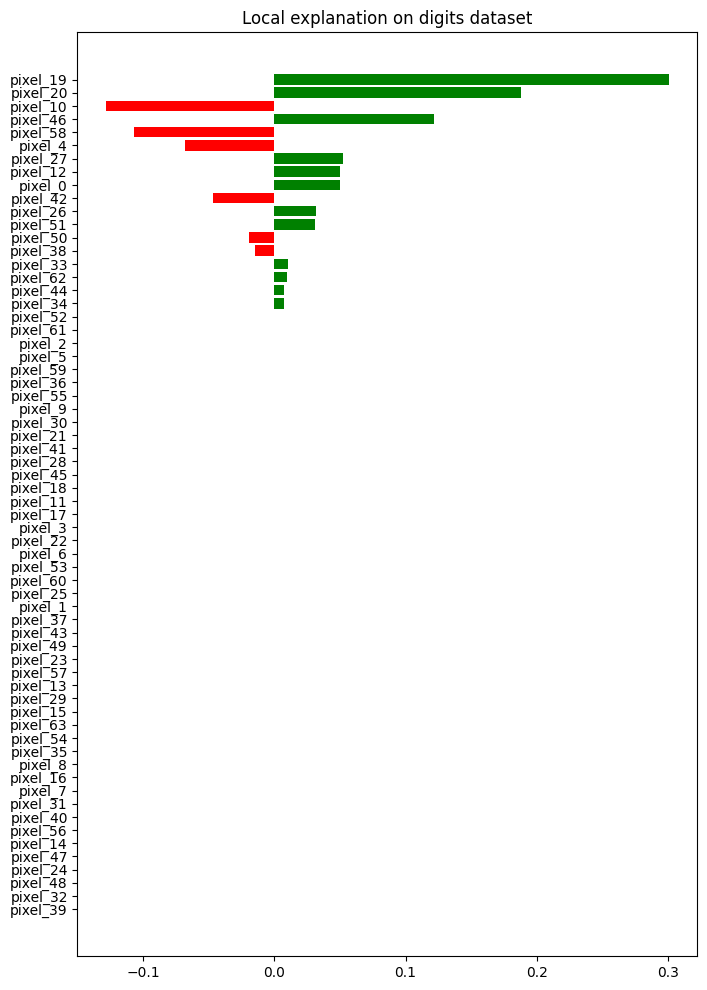

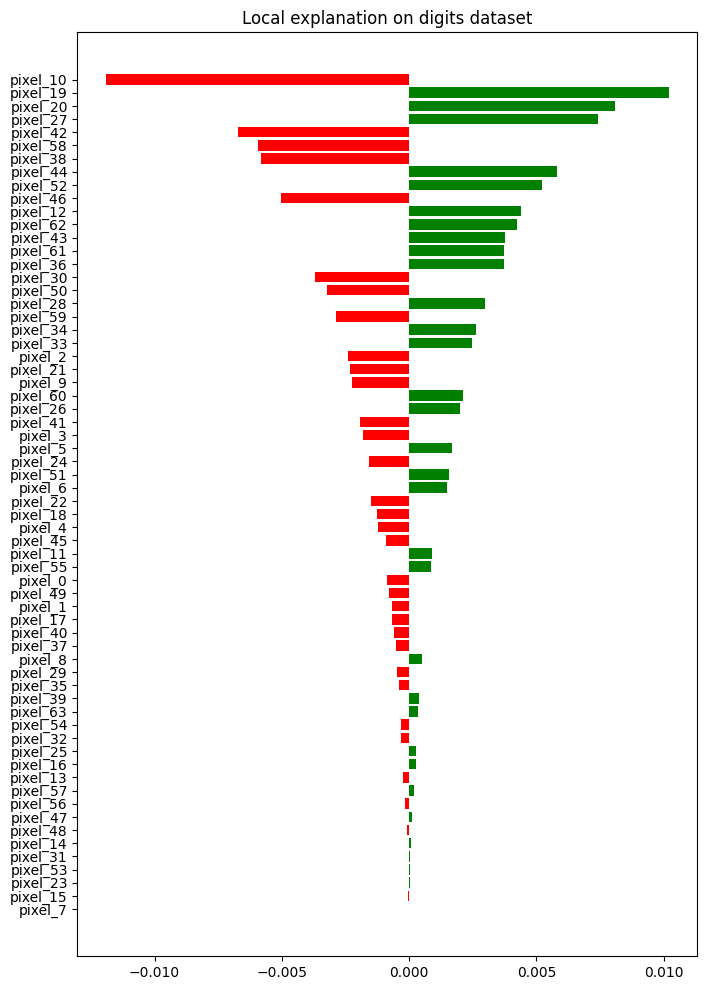

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 12)
fig = exp.as_pyplot_figure()
fig.set_size_inches(8, 12)
fig.axes[0].set_title("Local explanation on digits dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.set_size_inches(8, 12)
fig_ridge.axes[0].set_title("Local explanation on digits dataset")
plt.show()